<div style="
background-color:#d9f2dc;
border-left:8px solid #2e7d32;
padding:18px 22px;
margin:14px 0;
">

<h1 style="
margin-top:0;
margin-bottom:8px;
color:#0b3d0b;
font-weight:700;
font-size:30px;
letter-spacing:0.02em;
">
Monte Carlo Simulation in Proton Therapy
</h1>



<p style="
margin:0 0 8px 0;
color:#145214;
font-size:16px;
font-weight:700;
">
Dennis Shklyar
</p>


</div>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ipywidgets import interactive, fixed
import sympy as sp

<div style='background-color: #d9f2dc; padding: 12px; border-radius: 8px'>
<h1 style='color:#2e7d32; textalign:center;'>
Theory</h1>
</div>

### <span style="color: black;">Radiation Therapy</span>

Radiation therapy is a widely used method for treating localized cancers, in which high-energy radiation is used to damage and destroy cancerous cells. The main goal is to maximize the energy deposited in the tumor while minimizing damage to surrounding healthy tissue.

The effectiveness of treatment depends strongly on how radiation deposits energy as it travels through the body. Therefore, understanding the depth-dependent energy deposition of different types of radiation is important.

Two common ways of delivering radiation are using:

- Photon (X-ray or gamma rays) therapy
- Proton therapy

The difference in how these two radiation types deposit energy comes from how they interact with matter. This behavior is characterized by the Linear Energy Transfer (LET).

### <span style="color: black;">Linear Energy Transfer (LET)</span>

The Linear Energy Transfer (LET) is defined as:

$$
\text{LET} = \frac{dE}{dx}
$$

LET is the average energy locally deposited to a medium by a particle in a distance x.

- Low LET → spread-out energy deposition  
- High LET → localized energy deposition  

Photon beams deposit energy continuosly, which results in a significant entry and exit dose. On the other hand, proton beams have a distinct behavior, characterized by a Bragg Peak, where most of the energy is deposited near the end of the protons path with minimal exit dose beyond that point. 
This exact property is what makes proton therapy particularly advantageous.  

### <span style='color: black;'>Stopping Power

To understand why the Linear Energy Transfer (LET) increases as protons slow down, we must look at the physical mechanism for energy loss. 
For charged particled such as protons, energy is lost primarly through multiple Coulomb interactions with electrons. This process is quantified by the stopping power, defined as:

$$
S(E) = -\frac{dE}{dx}
$$

Stopping power represents the rate at which a charged particle loses kinetic energy per unit distance as it travels through matter, and it is described by the Bethe-Bloch equation:

$$ -\frac{dE}{dx} = K z^2 \frac{Z}{A} \frac{1}{\beta^2} \left[  \ln\left(\frac{2 m_e c^2 \beta^2 \gamma^2}{I^2}\right) - \beta^2 - \frac{\delta}{2} - \frac{C}{Z} \right] $$


$K$ = 0.307 MeV cm^2 mol^{-1}

$z$              = charge number of the incident particle  

$Z$              = atomic number of the material  

$A$              = atomic mass of the material  

$\beta = v/c$     

$\gamma = \frac{1}{\sqrt{1 - \beta^2}}$     

$I$              = mean excitation energy of the material   

$\delta$         = density effect correction (important at high energy)  

$\frac{C}{Z}$    = shell correction (important at low energy)

This equation is used in a clinical full-stopping model to treat patients. It accounts for for relativistic effects, as well as corrections at high and low energies. Our goal is to create a model, which captures the main physical processes in play:

- Charged particles lose energy through many interactions with other charged particles via the Coloumb Force, which is called multi-Coulomb Scattering.
- The LET increases as energy decreases. This is because energy loss increases as protons slow down.
- This results in more energy being deposited at the end of a protons path, which leads to the Bragg Peak.



### <span style='color: black;'>Model Assumptions

For proton therapy, the incident particle is always a proton, which leads to a fixed $z$ value:

$$ z = 1$$

We will also treat the interaction medium as fixed (such as water or bone), which is not true for clinical cases:

$$Z = const$$

$$A = const$$

$$I = const$$

We will also be dealing with non-relativistic protons, which means that we can use classical mechanics to describe the interactions:

$$ \beta \ll 1 $$

The shell correction and density effect corrections arise from solid state physics and atomic physics. They become relevant for high-energies and low energies respectivelly. For these reasons:

$$ \delta \approx 0 $$

$$ \frac{C}{Z} \approx 0 $$

As a result, our equation becomes (where $K_1$ and $C$ are constants):

$$-\frac{dE}{dx} = K_1 \frac{1}{\beta^2} \left[\ln\left(C \gamma^2 \beta^2\right) -\beta^2\right]$$


### <span style='color: black;'>Simplifying the Bethe-Bloch Equation

We can now do a Taylor expansion on the Logarithm terms:

$$ \ln(C \gamma^2 \beta^2) = \ln(C) + \ln(\beta^2) + \ln(\gamma^2)$$

We can expand:

$$ \gamma^2 = \frac{1}{ (1 - \beta^2) } $$

By using an infinite geometric series:

$$ \frac{1}{1-x} = 1 + x + x^2 + ... $$

Let $x = \beta^2:$

$$ \gamma^2 = 1 + \beta^2 + \beta^4 + ... $$

To first order:

$$ \gamma^2 \approx 1 + \beta^2 $$

We can also expand the Logarithm term:

$$ \ln(\gamma^2) = \ln(1 + \beta^2) $$

Write out the Taylor Series:

$$ \ln(1+x) = x - \frac{x^2}{2} + ... $$

Since we are dealing with non-relativistic protons, then $\beta \ll 1$

So we can approximate to first order:

$$ \ln(1 + \beta^2) \approx \beta^2 $$

Which implies:

$$ \ln (\gamma^2) \approx \ln(1 + \beta^2) \approx \beta^2 $$

Looking back at Bethe-Bloch Equation:

$$ -\frac{dE}{dx}  = K_1 \frac{1}{\beta^2} \left[ \ln(C) + \ln(\beta^2) + \ln(\gamma^2) - \beta^2\right] $$

And substituting our correction:

$$ -\frac{dE}{dx} = K_1 \frac{1}{\beta^2} \left[ \ln(C) + \ln(\beta^2) + \beta^2 - \beta^2\right] $$

$$ -\frac{dE}{dx} = K_1 \frac{1}{\beta^2} \left[ \ln(C) + \ln(\beta^2)\right] $$

Combining the Logarithm's together:

$$ -\frac{dE}{dx} = K_1 \frac{1}{\beta^2} \left[ \ln(C \beta^2)\right] $$

Rewriting in terms of the velocity:

$$ -\frac{dE}{dx} = K_1 \frac{c^2}{v^2} \ln\left(C \frac{v^2}{c^2}\right) $$

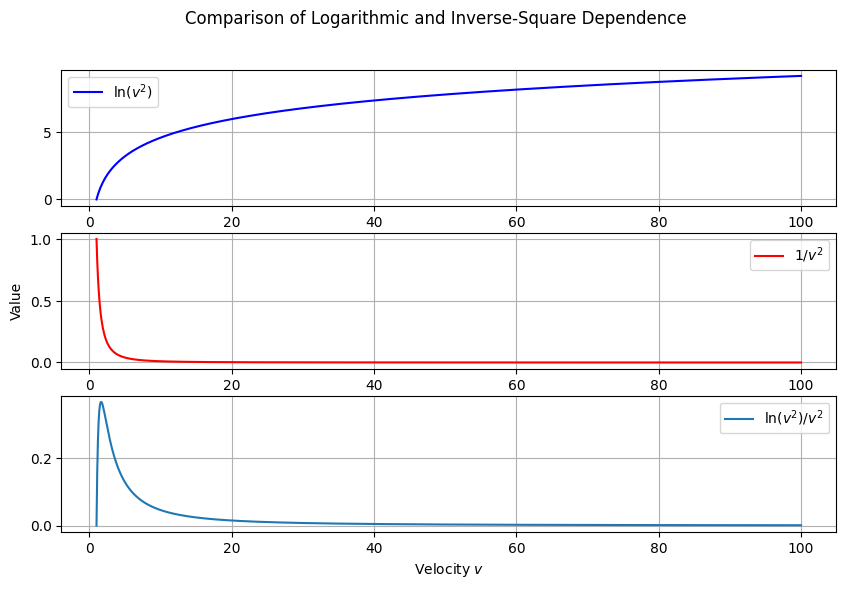

In [2]:
v = np.linspace(1, 100, 1000)

y1 = np.log(v**2)
y2 = 1/(v**2)
y3 = y1*y2

fig, axs = plt.subplots(3, 1, figsize = (10,6))

axs[0].plot(v, y1, 'b', label='ln($v^2$)')
axs[0].grid()
axs[0].legend()

axs[1].plot(v, y2, 'r', label='$1/v^2$')
axs[1].grid()
axs[1].legend()

axs[2].plot(v, y3, label='ln($v^2$)/$v^2$')
axs[2].grid()
axs[2].legend()

axs[2].set_xlabel('Velocity $v$')
axs[1].set_ylabel('Value')
plt.suptitle('Comparison of Logarithmic and Inverse-Square Dependence')
plt.show()

The logarithmic term varies much more slowly than the dominant $1/v^2$ dependence. Therefore, over a limited energy range, it can be treated as weakly varying and absorbed into an effective constant.

$$ K_1 \frac{c^2}{v^2} \ln\left(C \frac{v^2}{c^2}\right) \approx C_1 \frac{1}{v^2}$$

This results in the following simplified Bethe-Bloch Equation:

$$ -\frac{dE}{dx} = C_1 \frac{1}{v^2} $$

Where $C_1$ is a constant.

Since we are dealing with classical physics, we can re-write the kinetic energy as:

$$ E = \frac{m v^2}{2} $$

Isolating for $v^2$:

$$ v^2 = \frac{2E}{m} $$

Now writing the final version of the modified stopping law:

$$ \frac{dE}{dx} = - \frac{k}{E}  $$

Where $E$ is the kinetic energy of the proton, and $k$ is a constant.

We can now easily solve the differential equation using sympy. 

In [3]:

x,k = sp.symbols('x,k')
E = sp.Function('E')

eqn = E(x).diff(x) + k/(E(x))
Sol1, Sol2 = sp.dsolve(eqn, E(x))

E0 = sp.symbols('E0')
ics = {E(x).subs(x, 0): E0}

Sol2 = sp.dsolve(eqn, E(x), ics = ics)
print("The solution to the ODE with the IC's is:")
display(Sol2)


The solution to the ODE with the IC's is:


Eq(E(x), sqrt(E0**2 - 2*k*x))

### <span style='color: black;'>Simplified Stopping Law

After solving the ODE, we can find what the expected range for a proton will be depending on our initial energy $E_0$. The proton will stop when $E$ = 0. Therefore the Range $R$ will be:

$$ R = \frac{E_0^2}{2k}$$

The range of the proton, and where the depth of the Bragg Peak is determined by $E_0$.

This shows that, in our simplified model, the stopping power increases as the proton energy decreases. Physically, this explains why energy deposition becomes much larger near the end of the proton's path. 

### <span style='color: black;'>Multiple Coulomb Scattering 
While the stopping power describes how the proton loses energy, it does not determine its trajectory. In reality, as a proton travels through matter, it undergoes repeated Coulomb interactions with atomic nuclei. Each interaction produces a small angular deflection, and the overall change in direction is the cumulative effect of many interactions.

This process is known as multiple Coulomb scattering. Rather than a single large deflection, the proton experiences many small-angle deviations, which can be treated statistically. Since these deflections are approximately independent, the total angular deviation behaves like a random walk. As a result, the angular distribution can be approximated as Gaussian:

$$
\delta\theta \sim \mathcal{N}(0, \sigma_\theta^2)
$$

where $\sigma_\theta$ represents the standard deviation of the angular spread, and our mean is zero because there is no preferred direction for scattering.

A more complete description of multiple Coulomb scattering is given by the Highland formula, which provides an estimate for the root-mean-square (RMS) scattering angle:

$$
\theta_0 \approx \frac{13.6\,\text{MeV}}{\beta p} z\sqrt{\frac{x}{X_0}}
\left[1 + 0.038 \ln\left(\frac{x}{X_0}\right)\right]
$$

where:

$p$ is the proton momentum

$z$ is the charge number of the particle

$\beta = v/c$

$x$ is the thickness of material traversed 

$X_0$ is the radiation length of the medium 


### <span style='color: black;'>Simplified Scattering Model</span>

In this project, we do not use the full Highland formula directly. Instead, we use a simplified model to capture the main physical behavior.

First, we can look at the term:

$$
\sqrt{\frac{x}{X_0}}\left[1 + 0.038 \ln\left(\frac{x}{X_0}\right)\right]
$$

Since $\ln{x}$ varies much more slowly than $\sqrt{x}$, we can treat the term


$$
\left[1 + 0.038 \ln\left(\frac{x}{X_0}\right)\right]
$$

as weakly varying and absorbed into an effective constant. We therefore are left with:

$$
\theta_0 \approx \frac{13.6\,\text{MeV}}{\beta p} z\sqrt{\frac{x}{X_0}}
C_1
$$

But, since we are assuming a constant medium, we have

$$X_0=const$$

Therefore, we can write:

$$
\theta_0 \approx \frac{\sqrt{x}}{\beta p}
C_1
$$

Now, since our mean is zero, we have:

$$
\sigma_{theta}=\sqrt{\langle \theta^2 \rangle }= RMS = \theta_0
$$

So we can write our standard deviation as 

$$
\sigma_{theta}=\sigma_0\frac{\sqrt{ds}}{\beta p}
$$

But we want this in terms of energy, so we can remember that for non relativistic protons,

$$
E=\frac{p^2}{2m}= \frac{m v^2}{2}
$$

Isolating for p and v, we get:

$$
p = \sqrt{2mE}
$$

$$
v= \sqrt{\frac{2E}{m}}
$$

Which allows us to write the final expression for the standard deviation of the angular spread as:

$$
\sigma_{theta}=\sigma_0\frac{\sqrt{ds}}{E}
$$


We will now use this at each step of the simulation as the standard deviation of the Gaussian distribution, allowiing us to add multiple Coulomb scattering into the Monte Carlo trajectory.

### <span style='color: black;'>Limitations of the Model

Although this model captures the main physical ideas behind proton energy loss and the Bragg peak, it is still a simplified approximation.

The limitations of this model are:

- We assume the protons are non-relativistic.
- Nuclear interactions are ignored.
- The medium is assumed to be homogeneous.
- Multiple Coulomb scattering is treated in a simplified way.
- Several logarithmic terms are approximated as weakly varying.




<div style='background-color: #d9f2dc; padding: 12px; border-radius: 8px'>
<h1 style='color:#2e7d32; textalign:center;'>
Model Goals</h1>
</div>

The goal of this project is to build a simplified model of proton therapy that captures the physical behavior discussed in the theory section.

Rather than implementing a full clinical model, we focus on reproducing the essential features of proton energy deposition using the approximations discussed in the theory section.

The main objectives of this model are:

### <span style='color: black;'>Reproduce the Bragg Peak

Using the simplified stopping power equation

$$
\frac{dE}{dx} = -\frac{k}{E}
$$

we aim to simulate how protons lose energy as they travel through a medium and demonstrate the characteristic Bragg peak.


### <span style='color: black;'>Construct a Spread-Out Bragg Peak (SOBP)

In clinical proton therapy, tumors have a finite width and cannot be treated using a single Bragg peak. Instead, multiple proton beams with different initial energies are combined to create a Spread-Out Bragg Peak (SOBP).

In this project, we will:

- Superimpose multiple Bragg peaks
- Adjust their relative weights and energies
- Create a uniform dose region over a specified depth

This will be implemented as an interactive tool, with variability in the tumor depth and width.



### <span style='color: black;'>Simulate Proton Transport Using a Monte Carlo Simulation.

To model particle interactions we will implement a Monte Carlo simulation of proton trajectories to incorporate their stochastic behavior.

This includes:

- Sampling many individual proton paths
- Modeling energy loss step-by-step through the medium
- Incorporating lateral spread due to multiple Coulomb scattering



<div style='background-color: #d9f2dc; padding: 12px; border-radius: 8px'>
<h1 style='color:#2e7d32; textalign:center;'>
Code</h1>
</div>

### <span style='color: black;'>Euler Method 

The stopping power is originally written as $\frac{dE}{dx}$, which assumed straight-line motion. In the simulation, the proton undergoes scattering and follows a curved path in 2 dimensions. Instead, we now look at the energy deposited per unit path length:

$$
\frac{dE}{ds}
$$

For a small step size $ds$, the change in energy is approximated using the Euler Method:

$$
\Delta E \approx \frac{dE}{ds} \, ds
$$

At each step, the proton moves a distance $ds$ at an angle $\theta$, so its position is updated as

$$
x_{i+1} = x_i + ds\cos\theta_i, \quad
y_{i+1} = y_i + ds\sin\theta_i.
$$



### <span style='color: black;'>Model Parameters



In [4]:
#Creates a dictionary for often used values throughout the code.

baseline_params = {
    "E0": 100.0,         # Initial proton energy in MeV. Controls the penetration depth and Bragg peak location.
    "k": 330.0,         # Stopping power constant in the simplified model dE/dx = -k/E. Determines how quickly the proton loses energy.
    "ds": 0.05,        # Step size in cm
    "sigma0": 4.0,   # Scattering strength parameter for multiple Coulomb scattering. Controls lateral spreading of the beam.
    "x_max": 40.0,    # Maximum simulation depth in cm (size of the medium).
    "dose_bin_width": 0.10,  # Width of spatial bins used to accumulate deposited dose in cm.
    "num_protons": 400,      # Number of simulated protons.
    "keep_tracks": 60        # Number of individual proton trajectories to store for visualization.
}

baseline_params

{'E0': 100.0,
 'k': 330.0,
 'ds': 0.05,
 'sigma0': 4.0,
 'x_max': 40.0,
 'dose_bin_width': 0.1,
 'num_protons': 400,
 'keep_tracks': 60}

### <span style='color: black;'> Range Function


In [5]:

def theoretical_range(E0, k):
    """
    Computes the proton range for the simplified stopping-power model.

    """
    return E0**2/(2*k)


### <span style='color: black;'>Stepper Function



In [6]:
def ProtonStepper(E0 = baseline_params["E0"], k = baseline_params["k"], ds=baseline_params["ds"], sigma0=baseline_params["sigma0"],
                  x0=0.0, y0=0.0, theta0=0.0, x_max= baseline_params["x_max"], seed=None):
    """
    Models the motion of a proton through a uniform medium and returns the systems state step-by-step using a generator. 
    """
    
    # random number generator
    rng = np.random.default_rng(seed)

    # initialize the model
    x = x0
    y = y0
    theta = theta0
    E = E0
    dE_step = 0.0

    while True:
        model = {
            'x': x,
            'y': y,
            'theta': theta,
            'E': E,
            'dE': dE_step
        }
        yield model

        if E <= 0 or x > x_max:
            break

        # stopping power
        dEdx = -k / E
        dE_step = -dEdx * ds

        if dE_step > E:
            dE_step = E

        # scattering calculations
        sigma_theta = sigma0 * np.sqrt(ds) / E
        theta = theta + rng.normal(0, sigma_theta)

        # Euler update
        x = x + ds * np.cos(theta)
        y = y + ds * np.sin(theta)
        E = E - dE_step

### <span style='color: black;'>Single-Proton Plotting Function


In [7]:
def ProtonPlotter(data, label='', axs=None):
    """
    Plot one proton trajectory and its energy as a function of depth.
    """

    if axs is None:
        fig, axs = plt.subplots(1, 2, figsize=(10,6))

    axs[0].plot(data.x, data.y)
    axs[0].set_xlabel('Depth, x, cm')
    axs[0].set_ylabel('Lateral position, y, cm')
    axs[0].set_title('Single Proton Trajectory')
    axs[0].grid()

    axs[1].plot(data.x, data.E)
    axs[1].set_xlabel('Depth, x, cm')
    axs[1].set_ylabel('Energy, E, MeV')
    axs[1].set_title('Energy vs Depth')
    axs[1].grid()

    plt.show()
    plt.tight_layout()


### <span style='color: black;'>Single-Proton App



In [8]:
def SingleProtonApp(E0, sigma0):

    stepper = ProtonStepper(seed=3)

    proton_data = pd.DataFrame(stepper)

    ProtonPlotter(proton_data)

    R_theor = theoretical_range(E0, baseline_params["k"])
    R_sim = proton_data.x.iloc[-1]

    print(f'Theoretical range: R_theor = {R_theor:.3f}')
    print(f'Simulated range: R_sim   = {R_sim:.3f}')
    print(f'Projected vertical stopping point: y_stop = {proton_data.y.iloc[-1]:.3f}')


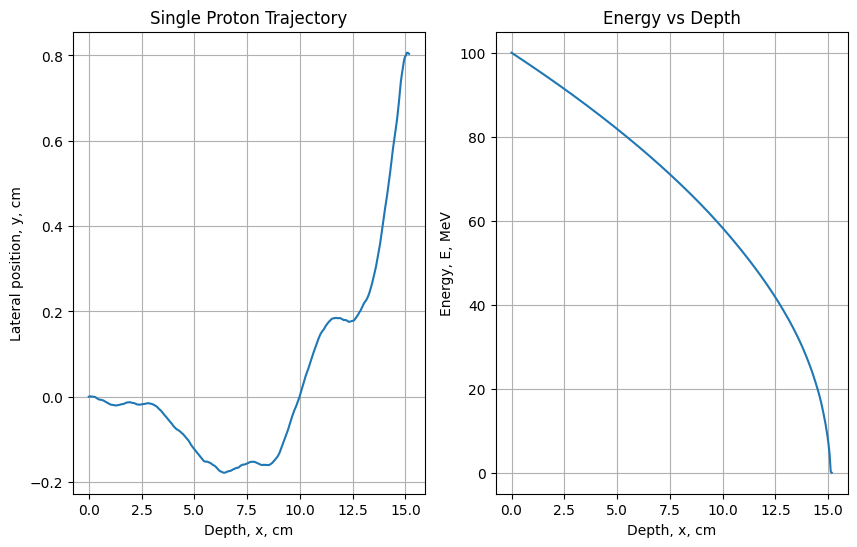

Theoretical range: R_theor = 15.152
Simulated range: R_sim   = 15.174
Projected vertical stopping point: y_stop = 0.804


<Figure size 640x480 with 0 Axes>

In [9]:
SingleProtonApp(E0=baseline_params["E0"], sigma0=baseline_params["sigma0"])


### <span style='color: black;'> Beam Monte Carlo Simulation 


In [10]:
def ProtonBeamModel(num_protons = baseline_params["num_protons"],
                    E0 = baseline_params["E0"], 
                    k = baseline_params["k"],
                    ds = baseline_params["ds"], 
                    sigma0 = baseline_params["sigma0"],
                    x_max = baseline_params["x_max"],
                    dose_bin_width = baseline_params["dose_bin_width"],
                    keep_tracks = baseline_params["keep_tracks"], seed=None):
    """
    Run a Monte Carlo beam simulation using the single-proton stepper. Shows where the energy is deposited along the trajectory of motion.
    Returns a dictionary containing all the parameters and results of the simulation.
    """

    #random number generator
    rng = np.random.default_rng(seed)

    #Create boundaries for depth bins, used for groupping energy deposition to build Bragg Peak. 
    x_edges = np.arange(0, x_max + dose_bin_width, dose_bin_width)

    # Create empty array to store deposited dose in each depth bin.
    dose_profile = np.zeros(len(x_edges) - 1)

    #Empty array to later store the stopping values for each proton horizontally and vertically.
    x_stop = []
    y_stop = []

    #Looks at full trajectory for protons. Later graphs them on one plot.
    tracks = []


    for i in range(num_protons):
        #generate random seed, we pick 2**24 to make sure no seeds are repeated
        proton_seed = int(rng.integers(0, 2**24))

        #generate a table of values to use for plotting
        stepper = ProtonStepper(E0 = E0, k = k, ds = ds, sigma0 = sigma0, x_max = x_max, seed = proton_seed)
        proton = pd.DataFrame(stepper)

        #Extract final horizontal and vertical value for each proton
        x_stop.append(proton.x.iloc[-1])
        y_stop.append(proton.y.iloc[-1])

        #We will only visualize a part of the trajectories. In case case: keep_tracks = 60
        if i < keep_tracks:
            tracks.append(proton)

        #Take all the proton’s depth positions except the first one, as dE = 0 for the first x_value.
        #Make a list of where energy is deposited and how much energy is deposited.
        x_values = proton.x.iloc[1:].to_numpy()
        dE_values = proton.dE.iloc[1:].to_numpy()

        # Find which bin each x value belongs to and shift by 1 back, as arrays start at 0. 
        bin_index = np.digitize(x_values, x_edges) - 1

        #Add energy deposited at each step into the correct depth bin
        for j in range(len(bin_index)):
            idx = bin_index[j]
            if idx >= 0 and idx < len(dose_profile):
                dose_profile[idx] += dE_values[j]

    #Compute the center of each depth bin for plotting the dose profile
    x_centers = []

    for i in range(len(x_edges) - 1):
        x_centers.append(0.5 * (x_edges[i] + x_edges[i+1]))


    #Return a dictionary containing all simulation results and parameters 
    beam = {
        'tracks': tracks,
        'x_stop': x_stop,
        'y_stop': y_stop,
        'dose_x': x_centers,
        'dose_profile': dose_profile,
        'E0': E0,
        'k': k,
        'sigma0': sigma0,
        'num_protons': num_protons
            }

    return beam


### <span style='color: black;'> Beam Simulation Plotting Function


In [11]:
def ProtonBeamPlotter(beam, label = '', axs = None):
    """
    Plot sample proton trajectories, the depth-dose curve (Bragg peak), and a histogram of stopping depths.
    """
    if axs is None:
        fig, axs = plt.subplots(1, 3, figsize=(14,6))

    #Plot sample proton trajectories
    for proton in beam['tracks']:
        axs[0].plot(proton.x, proton.y, alpha=0.6, linewidth=0.75)

    axs[0].set_xlabel('Depth, x, cm')
    axs[0].set_ylabel('Lateral position, y, cm')
    axs[0].set_title('Sample Proton Tracks')
    axs[0].grid()

    #Normalize the dose so the maximum value is 1 (relative dose) 
    dose = beam['dose_profile']

    #Normalize dose by the maximum value
    if max(dose) > 0:
        dose = dose/max(dose)

    axs[1].plot(beam['dose_x'], dose, linewidth = 2.0)
    axs[1].set_xlabel('Depth, x, cm')
    axs[1].set_ylabel('Relative deposited dose')
    axs[1].set_title('Bragg Peak')
    axs[1].grid()

    #Stopping-depth histogram
    axs[2].hist(beam['x_stop'], bins=20)
    axs[2].set_xlabel('Stopping depth, x, cm')
    axs[2].set_ylabel('Counts')
    axs[2].set_title('Stopping Depth Distribution')
    axs[2].grid()

    plt.tight_layout()
    plt.show()


### <span style='color: black;'> Beam Simulation App


In [12]:
def ProtonBeamApp(sigma0 = baseline_params["sigma0"]):

    beam = ProtonBeamModel( num_protons=baseline_params["num_protons"], E0=baseline_params["E0"],
                            k=baseline_params["k"], ds=baseline_params["ds"],
                            sigma0=sigma0, x_max=baseline_params["x_max"],
                            dose_bin_width=baseline_params["dose_bin_width"],
                            keep_tracks=baseline_params["keep_tracks"],
                            seed=1234) 

    ProtonBeamPlotter(beam)

    R_theor = theoretical_range(beam['E0'], beam['k'])

    #Average stopping depth
    avg_range = np.mean(beam['x_stop'])

    #Spread in stopping depth
    std_range = np.std(beam['x_stop'])

    #Average lateral stopping position
    avg_y = np.mean(beam['y_stop'])

    #Lateral spread of the beam
    std_vertical = np.std(beam['y_stop'])

    print(f'sigma0 = {sigma0:.3f}')
    print(f'Theoretical range: R_theor = {R_theor:.3f} cm')
    print(f'Average simulated range: R_avg =  {avg_range:.3f} +/- {std_range:.3f} cm')
    print(f'Average simulated lateral range: y_avg = {avg_y:.3f} +/- {std_vertical:.3f} cm')


In [13]:
interactive(ProtonBeamApp, sigma0=(0.0, 7.5, 0.25))


interactive(children=(FloatSlider(value=4.0, description='sigma0', max=7.5, step=0.25), Output()), _dom_classe…

### <span style='color: black;'> Comparing Several Scattering Strengths


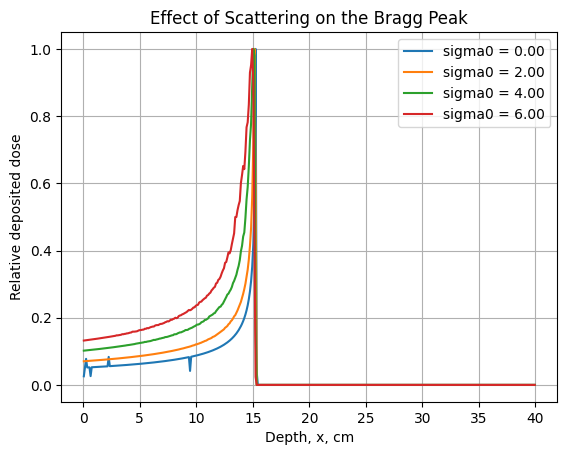

In [14]:
def BraggPeakComparison():

    """Compares Bragg Peaks for different values of sigma."""

    sigma_list = [0.0, 2.0, 4.0, 6.0]

    for sigma0 in sigma_list:
        beam = ProtonBeamModel(num_protons=300,
                               E0=baseline_params["E0"],
                               k=baseline_params["k"],
                               ds=baseline_params["ds"],
                               sigma0=sigma0,
                               x_max=baseline_params["x_max"],
                               dose_bin_width=baseline_params["dose_bin_width"],
                               keep_tracks=0,
                               seed=1234)

        dose = beam['dose_profile']

        if max(dose) > 0:
            dose = dose/max(dose)

        plt.plot(beam['dose_x'], dose, label = f'sigma0 = {sigma0:.2f}')

    plt.xlabel('Depth, x, cm')
    plt.ylabel('Relative deposited dose')
    plt.title('Effect of Scattering on the Bragg Peak')
    plt.legend()
    plt.grid()
    plt.show()

BraggPeakComparison()


### <span style='color: black;'> Spread-Out Bragg Peak (SOBP)

A single Bragg peak is narrow, so by itself it is only useful for a very thin target.
In the clinic, several proton beams with different initial energies are combined so that their Bragg peaks
occur at different depths. When these peaks are added together with suitable weights, the result is a
Spread-Out Bragg Peak (SOBP) that covers the full tumor thickness.

In the simple model used here, the range is

$$
R = \frac{E_0^2}{2k}.
$$

So if we want a Bragg peak at a chosen depth $R$, we can choose the corresponding beam energy from

$$
E_0 = \sqrt{2kR}.
$$

We will use this relation to choose a set of beam energies spanning the tumor region, then we will overlap
their individual depth-dose curves.

Each proton beam produces a depth-dose curve $D_i(x)$, where i is the energy layer. The total dose delivered is a weighted sum of these contributions:

$$
D_{\text{total}}(x) = \sum_{i=1}^{N} w_i \, D_i(x),
$$

where $w_i$ are the weights assigned to each beam.

To determine the optimal weights, we evaluate the dose at discrete depth points within the tumor region. This allows us to write the problem in matrix form:

$$
A \mathbf{w} \approx \mathbf{b}
$$

Here:
- $A$ is a matrix whose columns contain the dose-depth curve of each proton beam, and each row corresponds to a specific depth point inside the tumor
- $\mathbf{w}$ is the vector of unknown weights,
- $\mathbf{b}$ is the desired dose distribution .

In this case, we want our total dose to be the same everywhere along the tumor, so we choose b to be constant.


Because an exact solution may not exist, the weights are determined using the least-squares method, which minimizes the error:

$$
\min_{\mathbf{w}} \|A\mathbf{w} - \mathbf{b}\|^2
$$

This approach finds the set of weights that best approximates a uniform dose across the tumor. After these are found, the total dose is constructed by summing the contribution of each beam layer over all depths:

$$
D_{total}(x)= \sum_{i=1}^{N} w_iD_i(x)
$$

In this way, combining multiple energy layers with optimized weights produces a dose across the tumor, forming the spread out Bragg peak used in proton therapy.

In [15]:
def SOBPModel(tumor_start=14.0, tumor_width=6.0, n_layers=7,
              sigma0=4.0, num_protons_layer=160,
              dose_bin_width=baseline_params["dose_bin_width"],
              x_max=baseline_params["x_max"], seed=4321):
    
    """ Build a spread-out Bragg peak (SOBP) by combining several pristine Bragg peaks. """
    
    #Define the end of the tumor
    tumor_end = tumor_start + tumor_width
    
    # Choose the target ranges across the tumor
    range_list = np.linspace(tumor_start, tumor_end, n_layers)
    
    # Convert each range into an energy
    energy_list = np.sqrt(2 * baseline_params["k"] * range_list)
    
    # Create empty list to store the dose curves from each layer
    layer_dose = []
    

    for i in range(n_layers):
        beam = ProtonBeamModel(num_protons=num_protons_layer,
                               E0=energy_list[i],
                               k=baseline_params["k"],
                               ds=baseline_params["ds"],
                               sigma0=sigma0,
                               x_max=x_max,
                               dose_bin_width=dose_bin_width,
                               keep_tracks=0,
                               seed=seed + i)
        
        if i == 0:
            layer_x = np.array(beam["dose_x"])
        
        layer_dose.append(beam["dose_profile"])
    
    layer_dose = np.array(layer_dose)
    
    # Keep only the part inside the tumor
    tumor_mask = (layer_x >= tumor_start) & (layer_x <= tumor_end)
    
    A = layer_dose[:, tumor_mask].T
    b = np.ones(len(A))
    
    # Solve the least-squares problem
    AT = A.T
    ATA = np.dot(AT, A)
    ATb = np.dot(AT, b)
    weights = np.linalg.solve(ATA, ATb)
    
    # Remove negative weights
    for i in range(len(weights)):
        if weights[i] < 0:
            weights[i] = 0
    
    total_dose = weights[0] * layer_dose[0]

    for i in range(1, n_layers):
        total_dose = total_dose + weights[i] * layer_dose[i]
    
    sobp = {
        "dose_x": layer_x,
        "layer_dose": layer_dose,
        "weights": weights,
        "range_list": range_list,
        "energy_list": energy_list,
        "total_dose": total_dose,
        "tumor_start": tumor_start,
        "tumor_end": tumor_end,
        "sigma0": sigma0,
        "x_max": x_max
    }
    
    return sobp

### <span style='color: black;'> SOBP Plotting Function

In [16]:
def SOBPPlotter(sobp):

    """ Plot the pristine Bragg peaks and the combined spread-out Bragg peak. """

    x = sobp["dose_x"]

    dose_total = sobp["total_dose"]


    x_max = sobp["x_max"]

    plt.figure(figsize=(10,6))

    # Water before tumor
    plt.axvspan(0, sobp["tumor_start"], alpha=0.10)

    # Tumor region
    plt.axvspan(sobp["tumor_start"], sobp["tumor_end"], alpha=0.40)

    # Water after tumor
    plt.axvspan(sobp["tumor_end"], x_max, alpha=0.10)

    #Plot the contribution of each energy layer to the total dose
    for i in range(len(sobp["weights"])):
        if sobp["weights"][i] > 0:
            layer = sobp["weights"][i]*sobp["layer_dose"][i]
            if np.max(sobp["total_dose"]) > 0:
                layer = layer/np.max(sobp["total_dose"])
            plt.plot(x, layer, alpha=0.4)

    plt.plot(x, dose_total, linewidth=3, label='Combined SOBP')

    plt.xlabel('Depth x')
    plt.ylabel('Deposited dose')
    plt.title('Spread-Out Bragg Peak Across a Tumor Region')
    plt.xlim(0, x_max)
    plt.grid()
    plt.legend()
    plt.show()

    print(f'Tumor region: x = {sobp["tumor_start"]:.2f} to {sobp["tumor_end"]:.2f}')
    print('Beam energies used:')
    
    for i in range(len(sobp["energy_list"])):
        print(f'layer {i+1}: E0 = {sobp["energy_list"][i]:.3f}, weight = {sobp["weights"][i]:.3f}')


### <span style='color: black;'>SOBP App


In [17]:
def SOBPApp(tumor_start=14.0, tumor_width=6.0, n_layers=7, sigma0=4):

    sobp = SOBPModel(tumor_start=tumor_start,
                     tumor_width=tumor_width,
                     n_layers=n_layers,
                     sigma0=sigma0,
                     num_protons_layer=160,
                     dose_bin_width=baseline_params["dose_bin_width"],
                     x_max=40.0,
                     seed=4321)

    SOBPPlotter(sobp)


In [ ]:
interactive(SOBPApp,
            tumor_start=(8.0, 22.0, 1.0),
            tumor_width=(3.0, 10.0, 1.0),
            n_layers=(3, 10, 1),
            sigma0=(0.0, 7.5, 0.2))

interactive(children=(FloatSlider(value=14.0, description='tumor_start', max=22.0, min=8.0, step=1.0), FloatSl…